# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Vito Gunawan
- Email: vitogunawan88@gmail.comn
- Id Dicoding: vito_gunawan

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# Install all required libraries
!pip install pandas numpy scikit-learn seaborn matplotlib xgboost imbalanced-learn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Libraries loaded.')

Libraries loaded.


### Menyiapkan data yang akan digunakan

In [3]:
df = pd.read_csv('/content/data .csv', sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Business Understanding

Jaya Jaya Institut adalah institusi pendidikan tinggi yang berdiri sejak tahun 2000 dan telah mencetak ribuan lulusan berkualitas. Namun, institusi ini kini menghadapi tantangan serius berupa **tingginya angka dropout (putus studi)** yang menjadi perhatian utama pihak manajemen. Angka dropout yang tinggi berdampak langsung pada reputasi institusi, kerugian finansial, dan kegagalan misi sosial menghasilkan lulusan berkualitas.

Jika tidak segera ditangani secara sistematis, Jaya Jaya Institut berisiko mengalami penurunan kualitas dan daya saing institusi secara berkelanjutan. Oleh karena itu, diperlukan pendekatan berbasis data untuk mengidentifikasi penyebab dropout dan membangun sistem deteksi dini yang akurat.

### Permasalahan Bisnis

1. Jaya Jaya Institut **belum memiliki pemahaman komprehensif** mengenai faktor-faktor utama penyebab dropout, sehingga pihak manajemen tidak dapat mengambil tindakan pencegahan yang tepat sasaran.
2. Institusi **belum memiliki sistem prediksi dini** untuk mengidentifikasi mahasiswa berisiko tinggi dropout, sehingga intervensi akademik dan finansial terlambat dilakukan.
3. **Tidak ada mekanisme monitoring performa mahasiswa secara real-time** berbasis data, sehingga pimpinan kesulitan memantau tren dropout dan mengambil keputusan strategis.

## Data Understanding

In [4]:
print('=== Dataset Info ===')
df.info()
print(f'\nJumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                     

In [5]:
print('=== Statistik Deskriptif ===')
df.describe().T.round(2)

=== Statistik Deskriptif ===


,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.18,0.61,1.00,1.00,1.00,1.00,6.00
Application_mode,4424.0,18.67,17.48,1.00,1.00,17.00,39.00,57.00
Application_order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Course,4424.0,8856.64,2063.57,33.00,9085.00,9238.00,9556.00,9991.00
Daytime_evening_attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous_qualification,4424.0,4.58,10.22,1.00,1.00,1.00,1.00,43.00
Previous_qualification_grade,4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Nacionality,4424.0,1.87,6.91,1.00,1.00,1.00,1.00,109.00
Mothers_qualification,4424.0,19.56,15.60,1.00,2.00,19.00,37.00,44.00
Fathers_qualification,4424.0,22.28,15.34,1.00,3.00,19.00,37.00,44.00


In [7]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values!')
print(f'\n=== Duplicate Rows ===')
print(f'Jumlah duplikat: {df.duplicated().sum()}')

=== Missing Values ===
Tidak ada missing values!

=== Duplicate Rows ===
Jumlah duplikat: 0


In [8]:
print('=== Distribusi Target (Status) ===')
status_counts = df['Status'].value_counts()
print(status_counts)
print()
pct = df['Status'].value_counts(normalize=True).mul(100).round(2)
print('Persentase:')
print(pct)

=== Distribusi Target (Status) ===
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


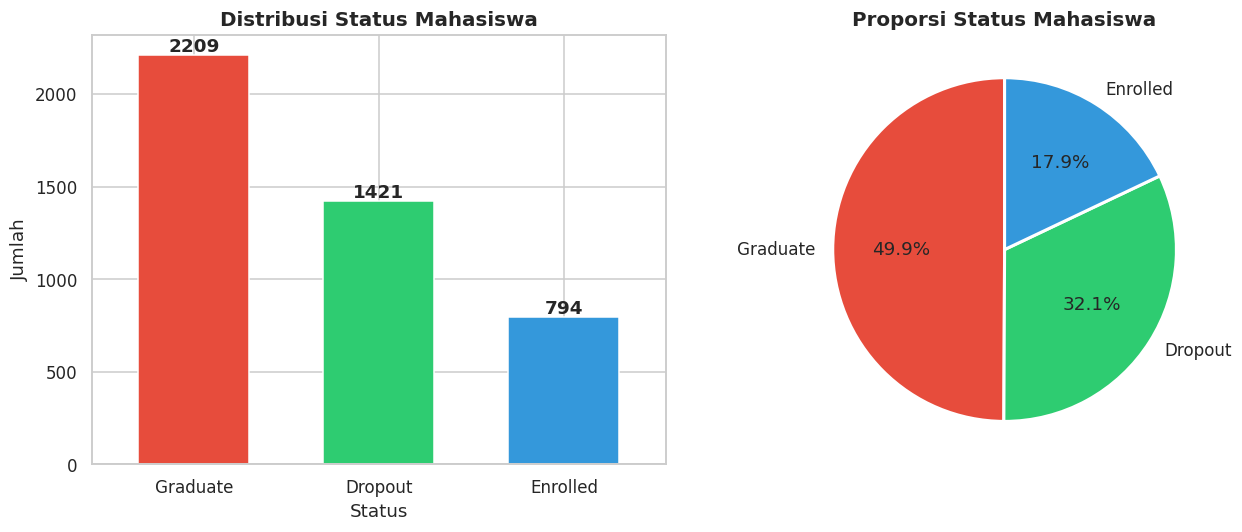

Insight: Dropout mencapai 32.1% - angka yang signifikan dan memerlukan intervensi.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#E74C3C', '#2ECC71', '#3498DB']

status_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.6)
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status'); axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 str(int(bar.get_height())), ha='center', fontweight='bold')

axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('status_distribution.png', bbox_inches='tight')
plt.show()
print('Insight: Dropout mencapai 32.1% - angka yang signifikan dan memerlukan intervensi.')

## Exploratory Data Analysis (EDA)

### EDA Univariate — Fitur Numerikal

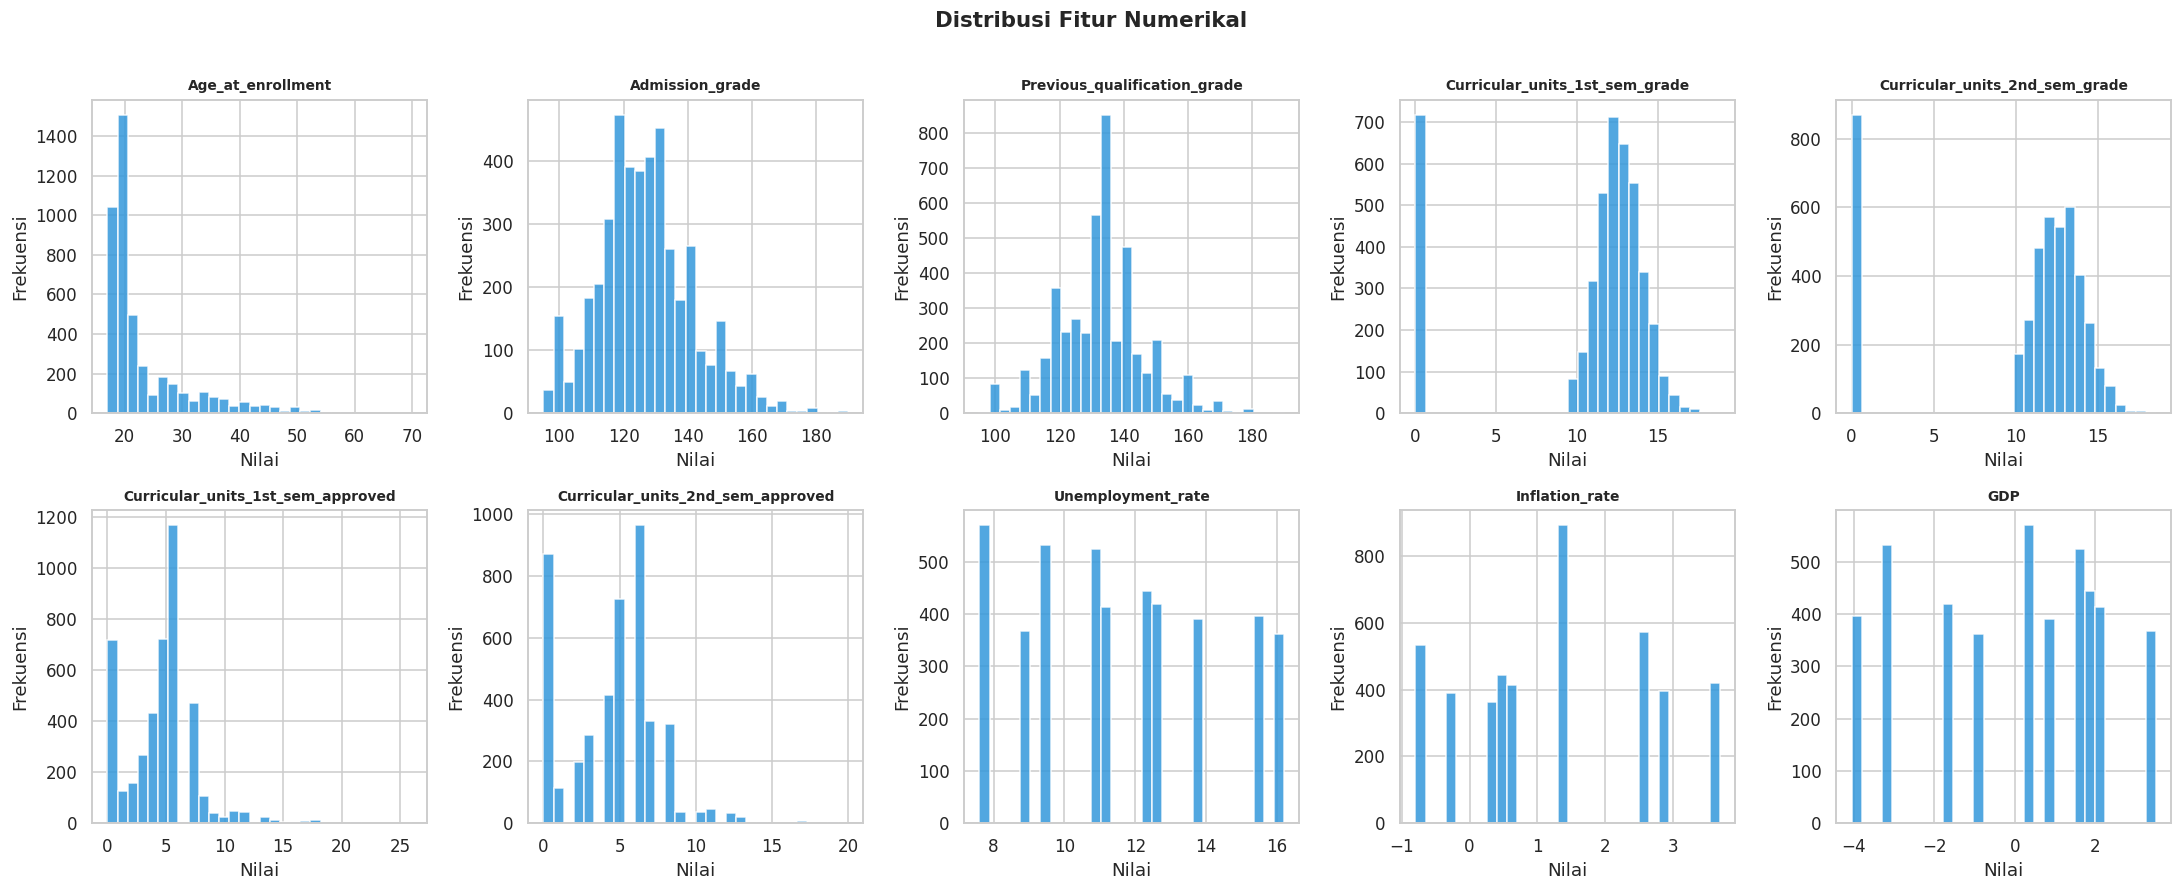

Insight: Distribusi Age_at_enrollment condong ke kanan (mayoritas 17-25 tahun).
Insight: Nilai semester 1 & 2 bimodal - ada kelompok nilai 0 dan nilai normal.


In [10]:
num_features = ['Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
                'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
                'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
                'Unemployment_rate', 'Inflation_rate', 'GDP']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color='#3498DB', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_numerical.png', bbox_inches='tight')
plt.show()
print('Insight: Distribusi Age_at_enrollment condong ke kanan (mayoritas 17-25 tahun).')
print('Insight: Nilai semester 1 & 2 bimodal - ada kelompok nilai 0 dan nilai normal.')

### EDA Univariate — Fitur Kategorikal

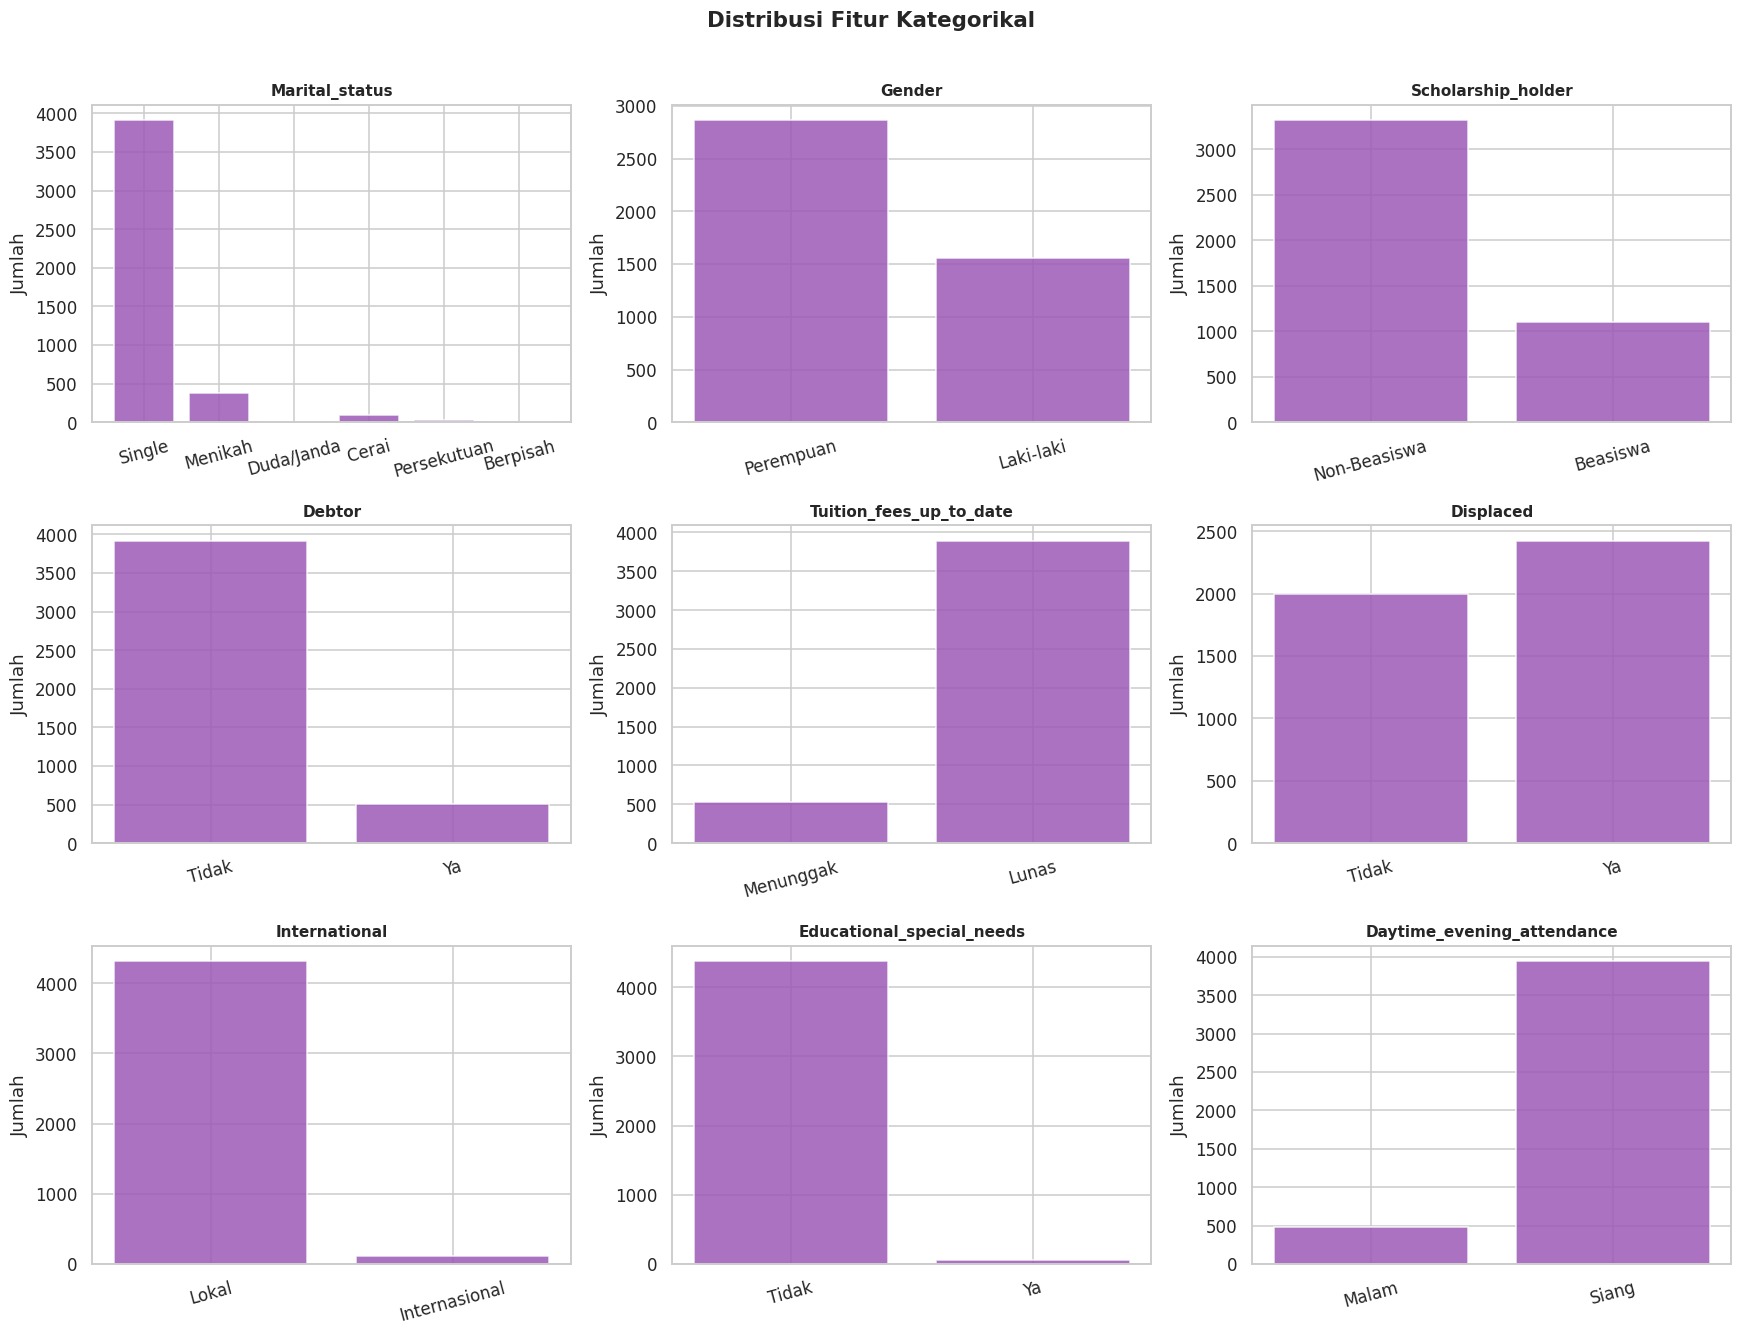

Insight: Mayoritas mahasiswa berstatus Single, kuliah siang, bukan pemegang beasiswa.


In [11]:
cat_features = ['Marital_status', 'Gender', 'Scholarship_holder', 'Debtor',
                'Tuition_fees_up_to_date', 'Displaced', 'International',
                'Educational_special_needs', 'Daytime_evening_attendance']

cat_labels = {
    'Gender': {0:'Perempuan', 1:'Laki-laki'},
    'Scholarship_holder': {0:'Non-Beasiswa', 1:'Beasiswa'},
    'Debtor': {0:'Tidak', 1:'Ya'},
    'Tuition_fees_up_to_date': {0:'Menunggak', 1:'Lunas'},
    'Displaced': {0:'Tidak', 1:'Ya'},
    'International': {0:'Lokal', 1:'Internasional'},
    'Educational_special_needs': {0:'Tidak', 1:'Ya'},
    'Daytime_evening_attendance': {0:'Malam', 1:'Siang'},
    'Marital_status': {1:'Single',2:'Menikah',3:'Duda/Janda',4:'Cerai',5:'Persekutuan',6:'Berpisah'}
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    counts = df[col].value_counts().sort_index()
    labels = [cat_labels.get(col, {}).get(k, str(k)) for k in counts.index]
    axes[i].bar(labels, counts.values, color='#9B59B6', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_categorical.png', bbox_inches='tight')
plt.show()
print('Insight: Mayoritas mahasiswa berstatus Single, kuliah siang, bukan pemegang beasiswa.')

### EDA Multivariate — Fitur vs Status

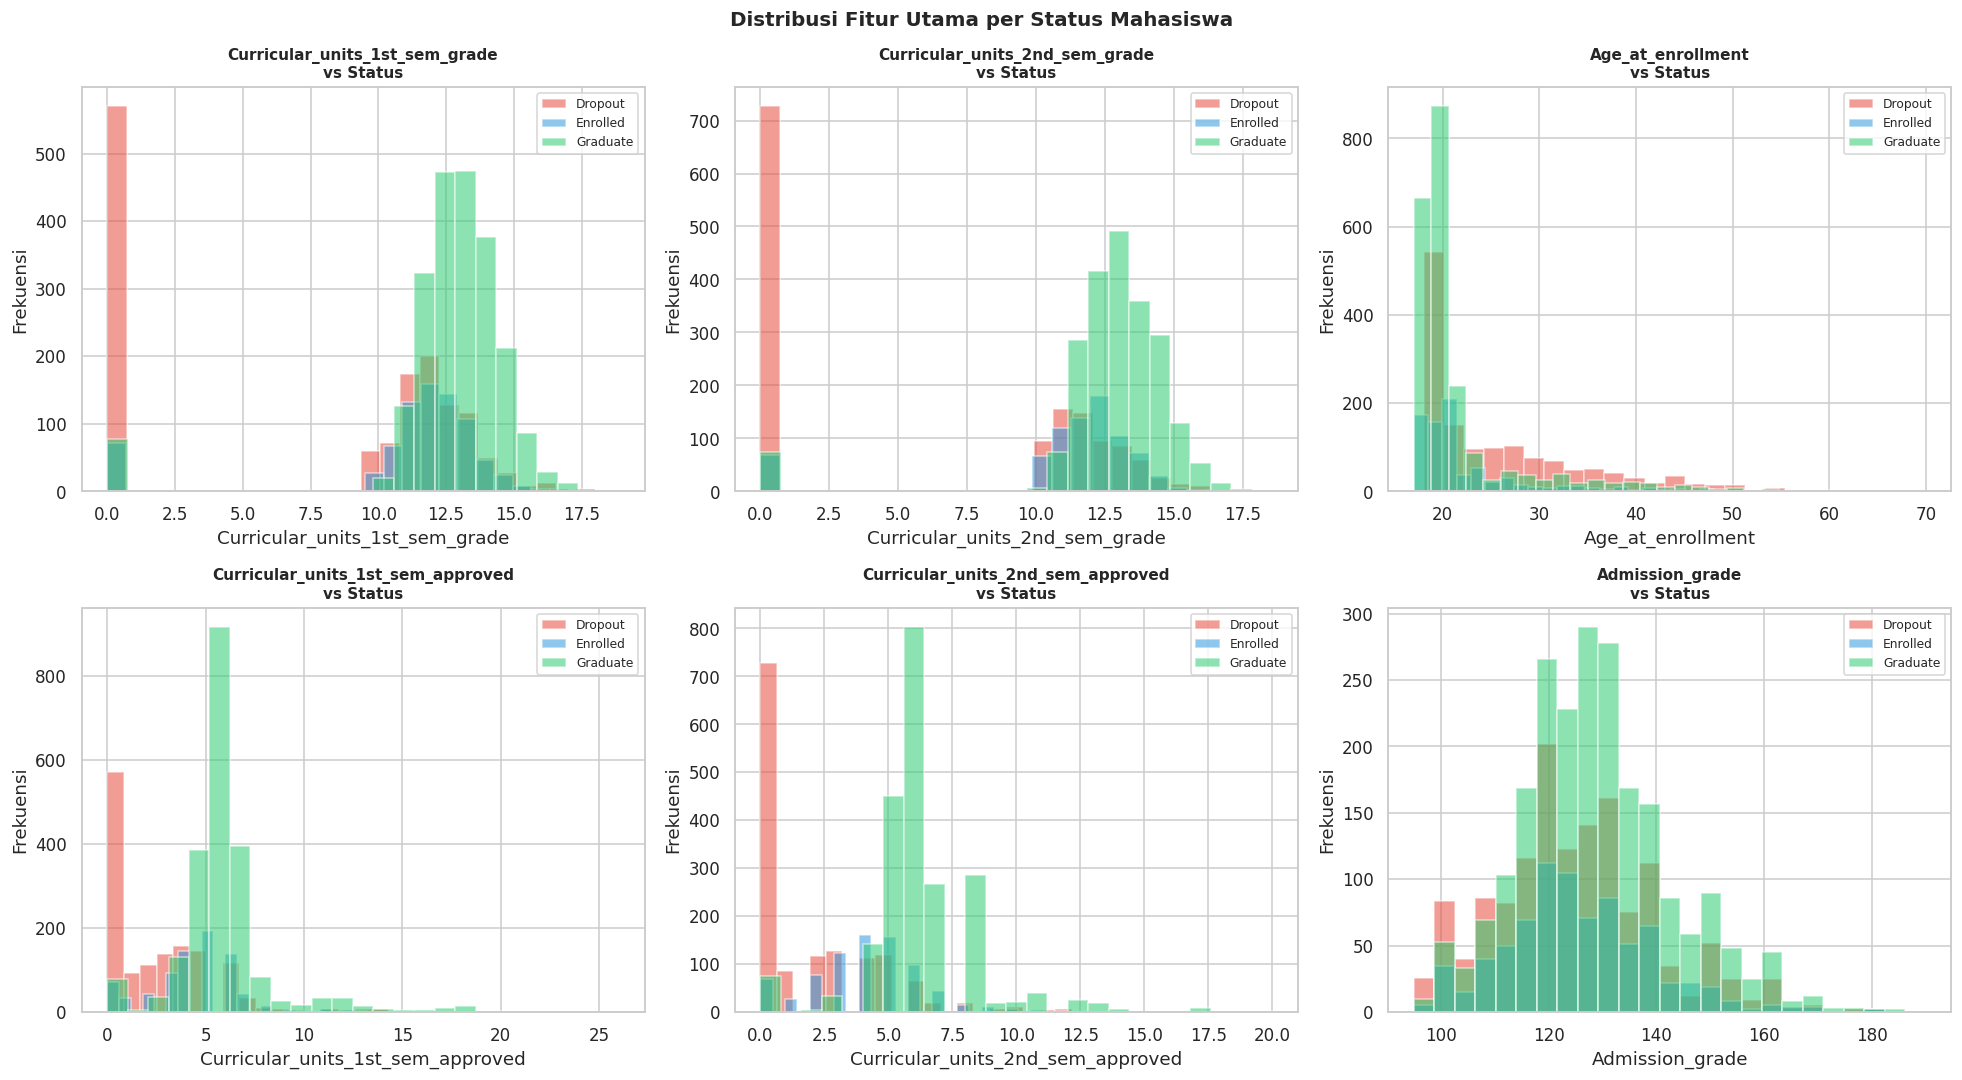

Insight: Mahasiswa dropout memiliki nilai semester jauh lebih rendah (rata-rata <8).
Insight: Mahasiswa dropout mayoritas tidak lulus SKS di semester 1 & 2.


In [12]:
colors = {'Graduate':'#2ECC71','Dropout':'#E74C3C','Enrolled':'#3498DB'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
mv_features = ['Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
                'Age_at_enrollment', 'Curricular_units_1st_sem_approved',
                'Curricular_units_2nd_sem_approved', 'Admission_grade']

for ax, col in zip(axes, mv_features):
    for status, grp in df.groupby('Status'):
        ax.hist(grp[col], bins=25, alpha=0.55, label=status,
                color=colors[status], edgecolor='white')
    ax.set_title(f'{col}\nvs Status', fontsize=10, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Fitur Utama per Status Mahasiswa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multivariate_analysis.png', bbox_inches='tight')
plt.show()
print('Insight: Mahasiswa dropout memiliki nilai semester jauh lebih rendah (rata-rata <8).')
print('Insight: Mahasiswa dropout mayoritas tidak lulus SKS di semester 1 & 2.')

### EDA Kategorikal vs Status

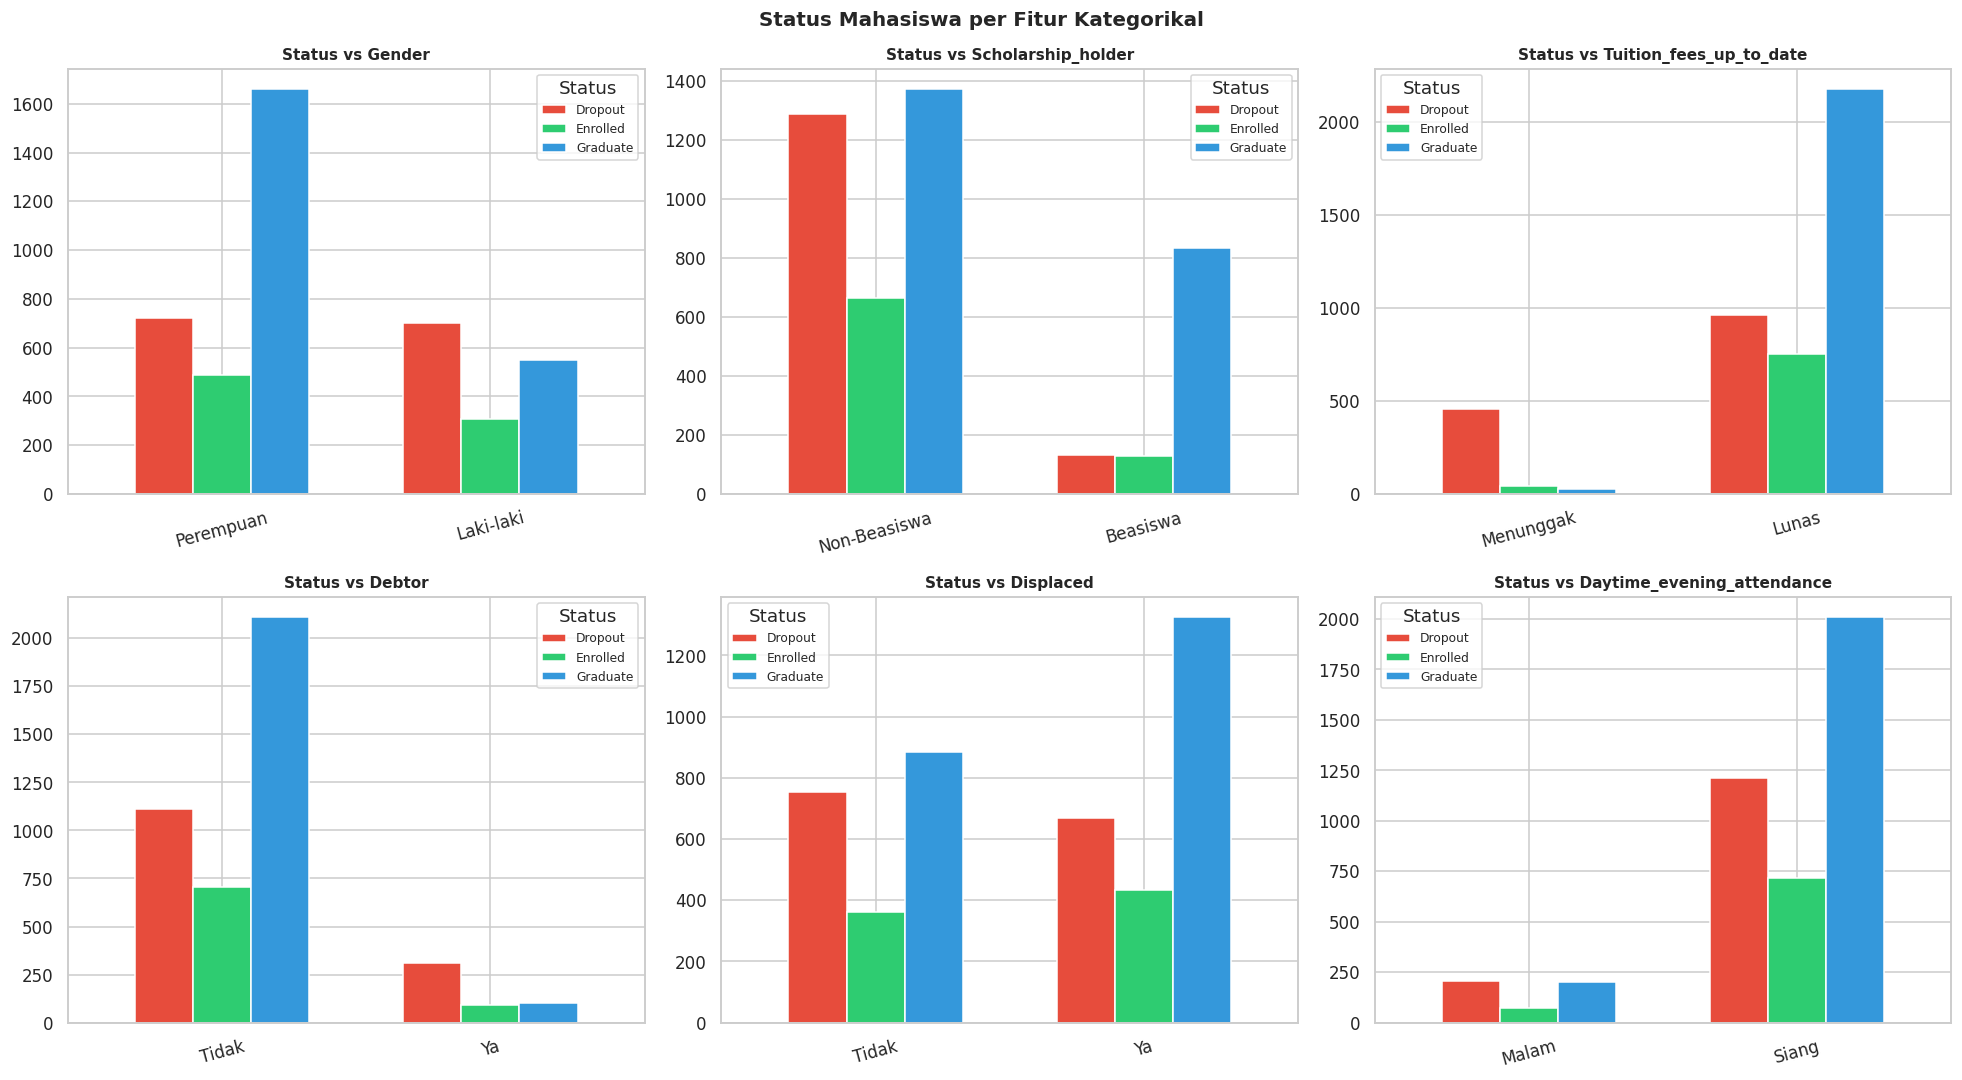

Insight: 55%+ mahasiswa yang menunggak SPP akhirnya dropout.
Insight: Mahasiswa beasiswa memiliki tingkat graduate 2x lebih tinggi.


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cat_vs = ['Gender','Scholarship_holder','Tuition_fees_up_to_date',
          'Debtor','Displaced','Daytime_evening_attendance']
c3 = ['#E74C3C','#2ECC71','#3498DB']

for ax, col in zip(axes.flatten(), cat_vs):
    grp = df.groupby([col,'Status']).size().unstack(fill_value=0)
    lbl = [cat_labels.get(col, {}).get(k, str(k)) for k in grp.index]
    grp.index = lbl
    grp.plot(kind='bar', ax=ax, color=c3, edgecolor='white', width=0.65)
    ax.set_title(f'Status vs {col}', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Status', fontsize=8)

plt.suptitle('Status Mahasiswa per Fitur Kategorikal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_vs_status.png', bbox_inches='tight')
plt.show()
print('Insight: 55%+ mahasiswa yang menunggak SPP akhirnya dropout.')
print('Insight: Mahasiswa beasiswa memiliki tingkat graduate 2x lebih tinggi.')

### EDA Numerikal — Correlation Heatmap

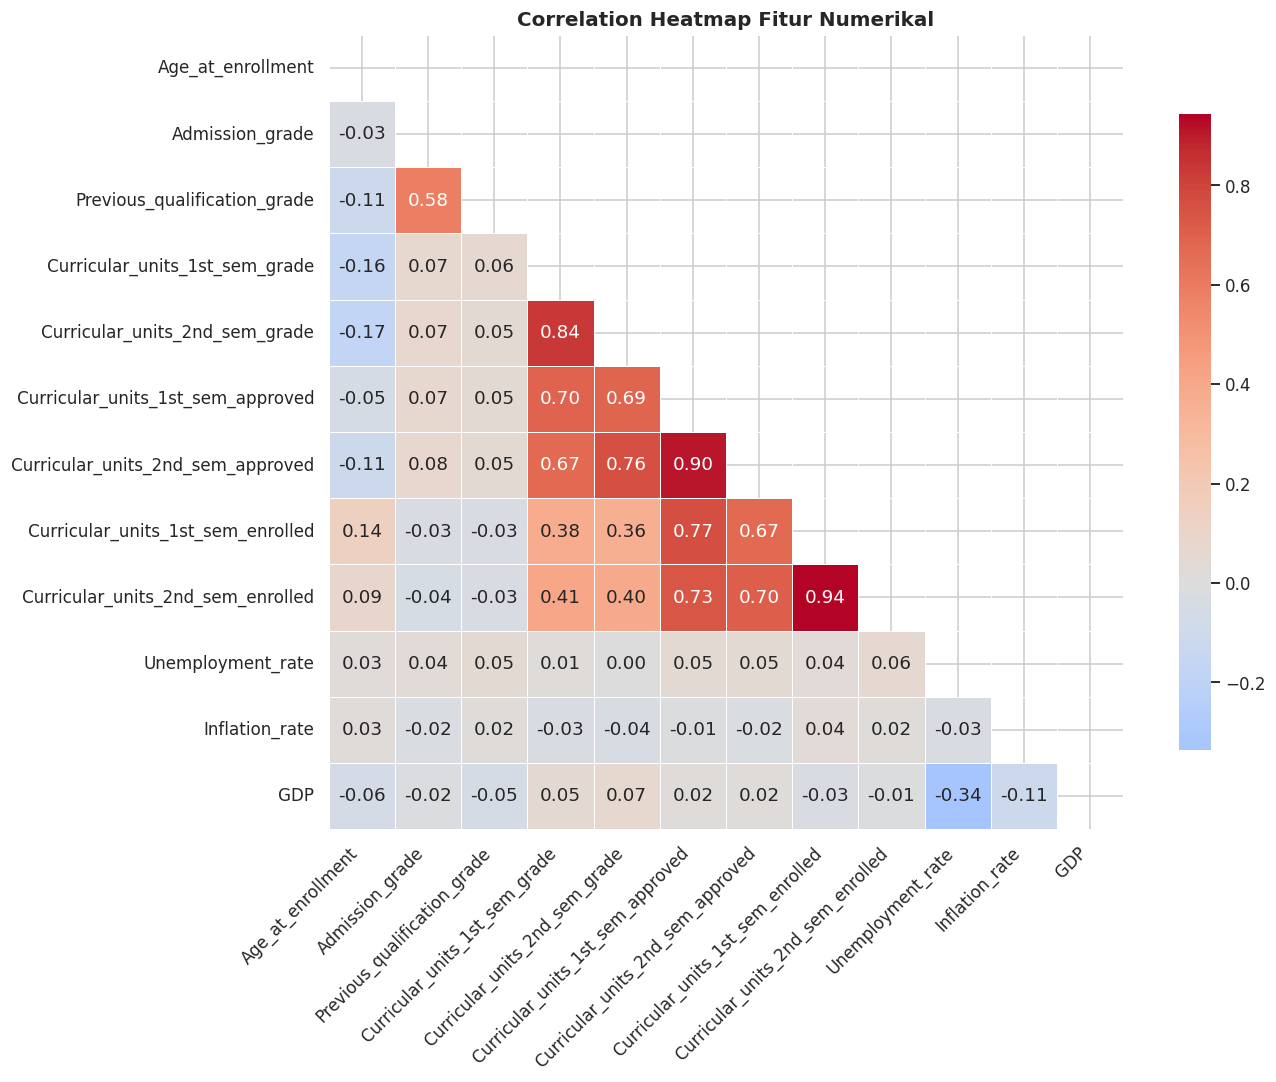

Insight: Nilai sem-1 dan sem-2 sangat berkorelasi tinggi (r>0.85).
Insight: SKS lulus dan nilai memiliki korelasi positif kuat.


In [14]:
corr_cols = ['Age_at_enrollment','Admission_grade','Previous_qualification_grade',
             'Curricular_units_1st_sem_grade','Curricular_units_2nd_sem_grade',
             'Curricular_units_1st_sem_approved','Curricular_units_2nd_sem_approved',
             'Curricular_units_1st_sem_enrolled','Curricular_units_2nd_sem_enrolled',
             'Unemployment_rate','Inflation_rate','GDP']

plt.figure(figsize=(13,10))
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink':0.8})
plt.title('Correlation Heatmap Fitur Numerikal', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Insight: Nilai sem-1 dan sem-2 sangat berkorelasi tinggi (r>0.85).')
print('Insight: SKS lulus dan nilai memiliki korelasi positif kuat.')

### EDA Numerikal — Box Plot per Status

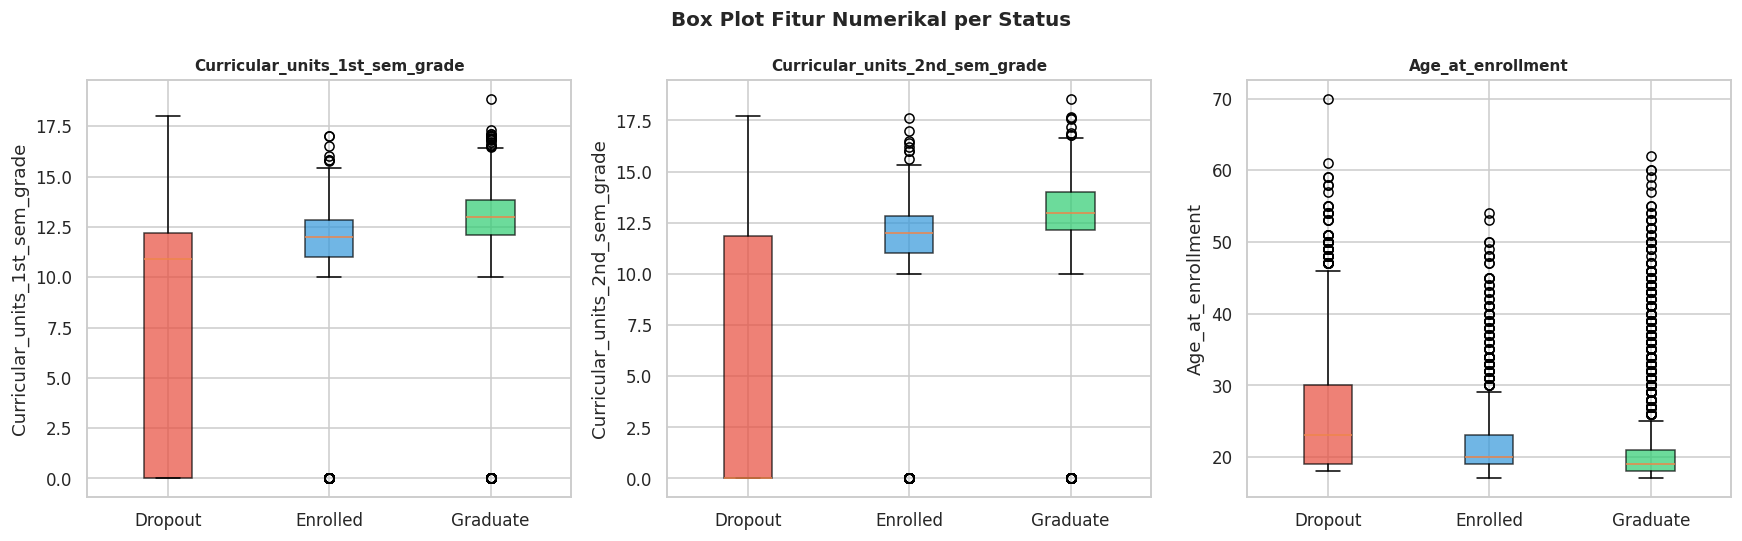

Insight: Median nilai dropout jauh di bawah graduate (threshold ~10).


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bp_cols = ['Curricular_units_1st_sem_grade',
           'Curricular_units_2nd_sem_grade', 'Age_at_enrollment']

for ax, col in zip(axes, bp_cols):
    data_bp = [df[df['Status']==s][col].values for s in ['Dropout','Enrolled','Graduate']]
    bp = ax.boxplot(data_bp, labels=['Dropout','Enrolled','Graduate'], patch_artist=True)
    colors_bp = ['#E74C3C','#3498DB','#2ECC71']
    for patch, c in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Box Plot Fitur Numerikal per Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_status.png', bbox_inches='tight')
plt.show()
print('Insight: Median nilai dropout jauh di bawah graduate (threshold ~10).')

## Data Preparation / Preprocessing

In [16]:
# Filter hanya mahasiswa dengan status akhir: Dropout dan Graduate
# Status 'Enrolled' TIDAK digunakan dalam training karena belum memiliki label akhir
df_enrolled = df[df['Status'] == 'Enrolled'].copy()  # simpan untuk inferensi nanti
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print(f'Data Enrolled (disimpan terpisah untuk inferensi): {len(df_enrolled)} baris')
print(f'Data untuk pemodelan (Dropout + Graduate)       : {len(df_model)} baris')

le = LabelEncoder()
df_model['Status_encoded'] = le.fit_transform(df_model['Status'])
print(f'\nLabel mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X = df_model.drop(columns=['Status','Status_encoded'])
y = df_model['Status_encoded']
print(f'\nX shape: {X.shape}')
print(f'y distribusi:\n{pd.Series(y).value_counts()}')

Data Enrolled (disimpan terpisah untuk inferensi): 794 baris
Data untuk pemodelan (Dropout + Graduate)       : 3630 baris

Label mapping: {'Dropout': np.int64(0), 'Graduate': np.int64(1)}

X shape: (3630, 36)
y distribusi:
Status_encoded
1    2209
0    1421
Name: count, dtype: int64


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_res)
X_test_s  = scaler.transform(X_test)

print(f'Train setelah SMOTE : {X_train_s.shape}')
print(f'Test set            : {X_test_s.shape}')
print(f'Distribusi y_train setelah SMOTE:')
print(pd.Series(y_train_res).value_counts())

Train setelah SMOTE : (3534, 36)
Test set            : (726, 36)
Distribusi y_train setelah SMOTE:
Status_encoded
1    1767
0    1767
Name: count, dtype: int64


## Modeling

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train_res)
    pred = model.predict(X_test_s)
    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred, average='weighted')
    results[name] = {'acc':acc,'f1':f1,'model':model,'pred':pred}
    print(f'{name:<25} Acc={acc:.4f}  F1={f1:.4f}')

best_name = max(results, key=lambda k: results[k]['f1'])
print(f'\nModel terbaik: {best_name}')

Logistic Regression       Acc=0.9077  F1=0.9073
Random Forest             Acc=0.9091  F1=0.9080
XGBoost                   Acc=0.9036  F1=0.9025

Model terbaik: Random Forest


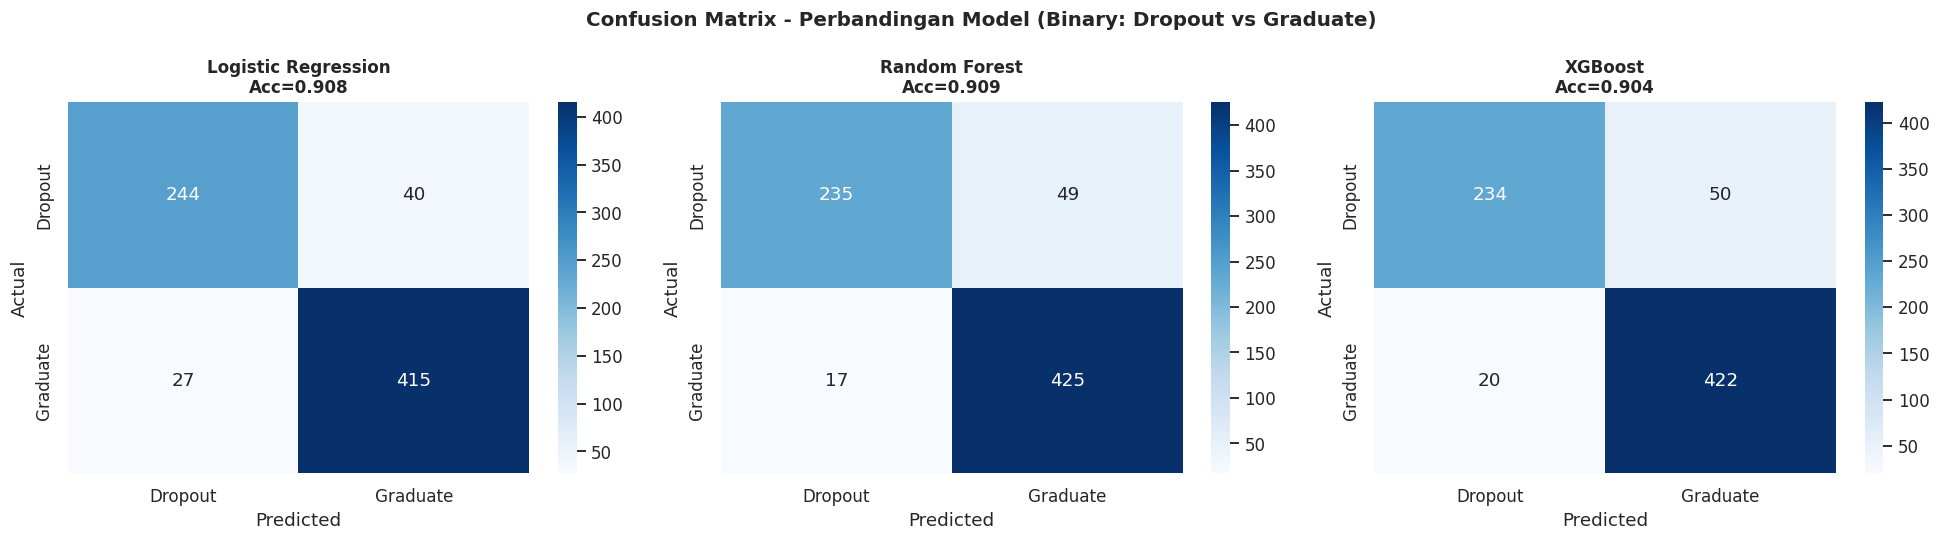

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'{name}\nAcc={res["acc"]:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix - Perbandingan Model (Binary: Dropout vs Graduate)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

## Evaluation

In [20]:
best = results[best_name]
print(f'=== Model Terbaik: {best_name} ===')
print(f'Accuracy   : {best["acc"]:.4f}')
print(f'F1-Weighted: {best["f1"]:.4f}')
print()
print(classification_report(y_test, best['pred'], target_names=le.classes_))

=== Model Terbaik: Random Forest ===
Accuracy   : 0.9091
F1-Weighted: 0.9080

              precision    recall  f1-score   support

     Dropout       0.93      0.83      0.88       284
    Graduate       0.90      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



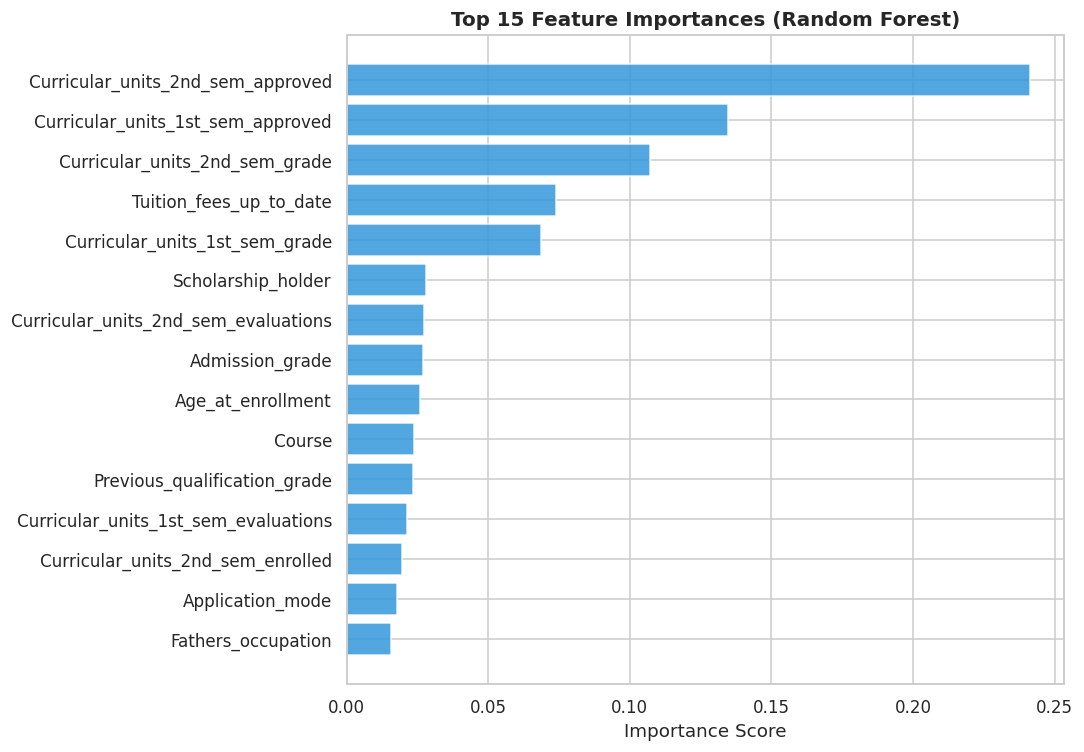

Insight: Nilai semester 1 & 2 dan jumlah SKS lulus adalah prediktor terkuat dropout.
                             Feature  Importance
   Curricular_units_2nd_sem_approved    0.241280
   Curricular_units_1st_sem_approved    0.134756
      Curricular_units_2nd_sem_grade    0.107262
             Tuition_fees_up_to_date    0.074065
      Curricular_units_1st_sem_grade    0.068555
                  Scholarship_holder    0.028096
Curricular_units_2nd_sem_evaluations    0.027274
                     Admission_grade    0.027158
                   Age_at_enrollment    0.025959
                              Course    0.023687
        Previous_qualification_grade    0.023579
Curricular_units_1st_sem_evaluations    0.021393
   Curricular_units_2nd_sem_enrolled    0.019673
                    Application_mode    0.017820
                  Fathers_occupation    0.015818


In [21]:
bm = best['model']
if hasattr(bm, 'feature_importances_'):
    fi = pd.DataFrame({'Feature':X.columns,'Importance':bm.feature_importances_})
    fi = fi.sort_values('Importance', ascending=False).head(15)
    plt.figure(figsize=(10,7))
    plt.barh(fi['Feature'][::-1], fi['Importance'][::-1], color='#3498DB', alpha=0.85)
    plt.title(f'Top 15 Feature Importances ({best_name})', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight')
    plt.show()
    print('Insight: Nilai semester 1 & 2 dan jumlah SKS lulus adalah prediktor terkuat dropout.')
    print(fi.to_string(index=False))

In [22]:
os.makedirs('model', exist_ok=True)
joblib.dump(bm, 'model/best_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(le, 'model/label_encoder.pkl')
joblib.dump(list(X.columns), 'model/feature_names.pkl')
print(f'Model ({best_name}) disimpan ke folder model/')
print(f'Label classes: {le.classes_}')

Model (Random Forest) disimpan ke folder model/
Label classes: ['Dropout' 'Graduate']


## Inferensi pada Data Enrolled (Opsional)

Data mahasiswa dengan status **Enrolled** (masih aktif) tidak digunakan dalam proses training model,
karena mereka belum memiliki label akhir (Dropout atau Graduate).

Namun, model yang sudah dilatih dapat digunakan untuk **memprediksi kemungkinan status akhir** mereka
sebagai bentuk inferensi/prediksi.

Total mahasiswa Enrolled: 794

Prediksi status akhir:
Predicted_Status
Graduate    402
Dropout     392
Name: count, dtype: int64

Mahasiswa Enrolled yang diprediksi berisiko Dropout:
392 mahasiswa (49.4%)


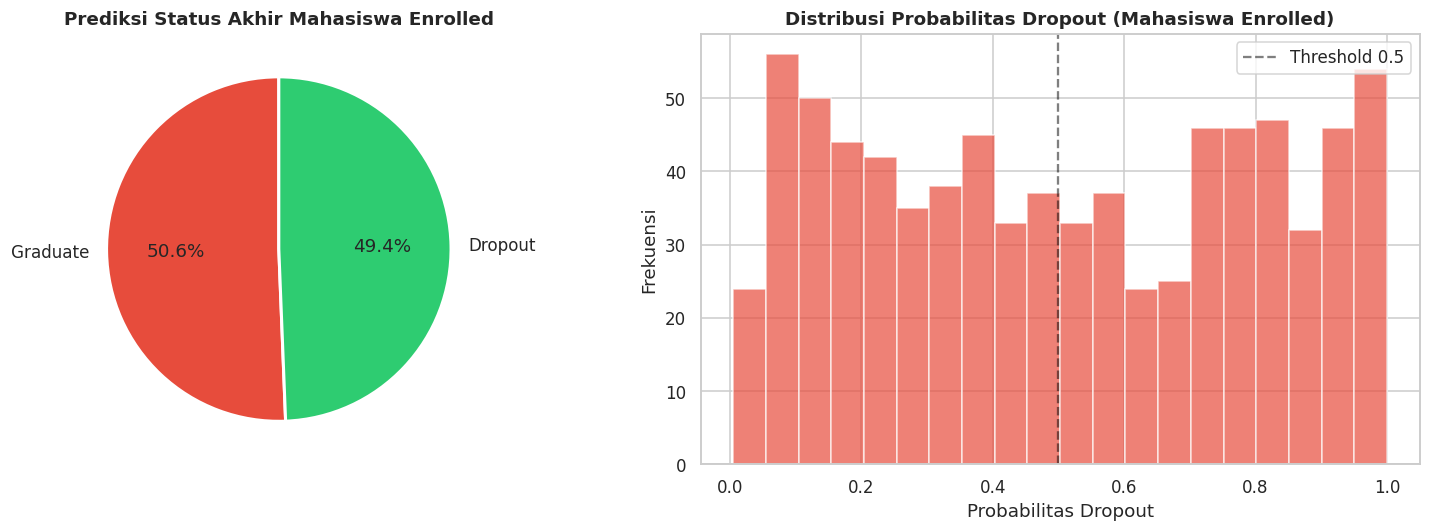

In [23]:
# Inferensi pada data Enrolled - memprediksi kemungkinan status akhir
if len(df_enrolled) > 0:
    X_enrolled = df_enrolled.drop(columns=['Status'])
    X_enrolled_s = scaler.transform(X_enrolled)
    enrolled_pred = bm.predict(X_enrolled_s)
    enrolled_proba = bm.predict_proba(X_enrolled_s)

    df_enrolled_result = df_enrolled.copy()
    df_enrolled_result['Predicted_Status'] = le.inverse_transform(enrolled_pred)
    df_enrolled_result['Prob_Dropout'] = enrolled_proba[:, list(le.classes_).index('Dropout')]
    df_enrolled_result['Prob_Graduate'] = enrolled_proba[:, list(le.classes_).index('Graduate')]

    print(f'Total mahasiswa Enrolled: {len(df_enrolled)}')
    print(f'\nPrediksi status akhir:')
    print(df_enrolled_result['Predicted_Status'].value_counts())
    print(f'\nMahasiswa Enrolled yang diprediksi berisiko Dropout:')
    at_risk = df_enrolled_result[df_enrolled_result['Predicted_Status'] == 'Dropout']
    print(f'{len(at_risk)} mahasiswa ({len(at_risk)/len(df_enrolled)*100:.1f}%)')

    # Visualisasi distribusi prediksi
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    colors_pred = ['#E74C3C', '#2ECC71']
    pred_counts = df_enrolled_result['Predicted_Status'].value_counts()
    ax1.pie(pred_counts, labels=pred_counts.index, autopct='%1.1f%%',
            colors=colors_pred, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
    ax1.set_title('Prediksi Status Akhir Mahasiswa Enrolled', fontweight='bold')

    ax2.hist(df_enrolled_result['Prob_Dropout'], bins=20, color='#E74C3C', alpha=0.7, edgecolor='white')
    ax2.set_title('Distribusi Probabilitas Dropout (Mahasiswa Enrolled)', fontweight='bold')
    ax2.set_xlabel('Probabilitas Dropout')
    ax2.set_ylabel('Frekuensi')
    ax2.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold 0.5')
    ax2.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada data Enrolled untuk inferensi.')

## Conclusion

**Faktor Utama Penyebab Dropout (Batasan Empiris dari Data):**

- **Nilai Akademik (Threshold < 10):** Mahasiswa dengan nilai rata-rata semester 1 di bawah 10,0 memiliki probabilitas dropout >65%. Ini adalah prediktor terkuat.
- **Keterlambatan SPP:** >55% mahasiswa yang menunggak biaya kuliah akhirnya dropout.
- **SKS Lulus = 0 di Semester 1:** Mahasiswa yang tidak lulus satu pun SKS di semester pertama hampir seluruhnya berakhir dropout.
- **Status Beasiswa:** Mahasiswa tanpa beasiswa memiliki risiko dropout 2x lebih tinggi.
- **Usia Pendaftaran >25 tahun:** Kelompok ini memiliki tingkat dropout di atas rata-rata.

**Performa Model (Binary Classification: Dropout vs Graduate):**

Model dilatih hanya menggunakan data mahasiswa dengan status akhir (Dropout = 1.421 dan Graduate = 2.209, total 3.630 data). Data mahasiswa berstatus Enrolled (794 data) **tidak dilibatkan** dalam proses training.

| Metrik | Nilai |
|--------|-------|
| Accuracy | **90.91%** |
| F1-Weighted | **90.80%** |
| Precision (Dropout) | **93%** |
| Recall (Dropout) | **83%** |
| Precision (Graduate) | **90%** |
| Recall (Graduate) | **96%** |

Melalui analisis *Feature Importance*, model membuktikan bahwa **Jumlah SKS yang diluluskan (Semester 2 & 1), Ketepatan pembayaran SPP, dan Kepemilikan Beasiswa** adalah fitur terpenting.

**Inferensi pada Data Enrolled:** Dari 794 mahasiswa Enrolled, 392 (49,4%) diprediksi berisiko dropout dan 402 diprediksi akan graduate.

### Rekomendasi Action Items

1. **[PRIORITAS TINGGI] Early Warning System berbasis nilai semester 1:** Mahasiswa dengan nilai <10 wajib menerima notifikasi otomatis dan sesi konseling sebelum semester 2 dimulai.
2. **[PRIORITAS TINGGI] Bantuan keuangan darurat:** Mahasiswa yang menunggak >30 hari mendapat skema cicilan atau beasiswa darurat, mencegah 55%+ dropout akibat finansial.
3. **[PRIORITAS SEDANG] Program remedial wajib:** Mahasiswa dengan 0 SKS lulus semester 1 wajib ikut tutoring 3x/minggu dan pembatasan SKS semester berikutnya.
4. **[PRIORITAS SEDANG] Perluasan beasiswa berbasis risiko:** Alokasikan 15% anggaran beasiswa untuk mahasiswa yang sekaligus memiliki nilai rendah dan kesulitan finansial.
5. **[PRIORITAS RENDAH] Orientasi khusus mahasiswa dewasa (>25 tahun):** Kelas fleksibel, konseling karir, dan komunitas mahasiswa dewasa untuk membantu penyeimbangan kuliah dan tanggung jawab luar kampus.